# Lecture 3 — From phase to collective synchronization


In [1]:
# Housekeeping code...
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from IPython.display import HTML, Video

if Path("../media").exists():
    MEDIA = Path("../media")
elif Path("media").exists():
    MEDIA = Path("media")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

TAU = 2 * np.pi
BLUE = "#3B6FB6"
ORANGE = "#D97706"
GOLD = "#C9A227"
PINK = "#B64E77"
OLIVE = "#718355"
INK = "#263238"
GREY = "#9AA0A6"
LIGHT = "#E7EAED"
rng = np.random.default_rng(567)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

def movie(filename, width=520):
    return Video(
        str(MEDIA / filename),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

def wrap_phase(theta):
    return (np.asarray(theta) + np.pi) % TAU - np.pi

def order_parameter(theta, axis=-1):
    return np.mean(np.exp(1j * np.asarray(theta)), axis=axis)

def kuramoto_rhs(theta, omega, coupling):
    mean_field = order_parameter(theta)
    return omega + coupling * np.imag(mean_field * np.exp(-1j * theta))

def simulate_kuramoto(
    omega, coupling, theta0, *, t_end, dt=0.01, save_every=1
):
    omega = np.asarray(omega, dtype=float)
    theta = np.asarray(theta0, dtype=float).copy()
    if omega.ndim != 1 or theta.shape != omega.shape:
        raise ValueError("omega and theta0 must have the same one-dimensional shape")
    n_steps = int(np.ceil(t_end / dt))
    save_steps = np.arange(0, n_steps + 1, save_every)
    times = np.empty(save_steps.size)
    phases = np.empty((save_steps.size, omega.size))
    times[0], phases[0] = 0.0, theta
    save_index = 1

    for step in range(1, n_steps + 1):
        slope = kuramoto_rhs(theta, omega, coupling)
        midpoint = theta + 0.5 * dt * slope
        theta += dt * kuramoto_rhs(midpoint, omega, coupling)
        if save_index < save_steps.size and step == save_steps[save_index]:
            times[save_index] = step * dt
            phases[save_index] = theta
            save_index += 1
    return times, phases

def simulate_relative_phase(
    detuning, coupling, phi0, *, t_end, dt=0.01
):
    n_steps = int(np.ceil(t_end / dt))
    times = np.arange(n_steps + 1) * dt
    phases = np.empty(n_steps + 1)
    phases[0] = phi0

    for step in range(n_steps):
        slope = detuning - coupling * np.sin(phases[step])
        midpoint = phases[step] + 0.5 * dt * slope
        phases[step + 1] = phases[step] + dt * (
            detuning - coupling * np.sin(midpoint)
        )
    return times, phases

def observed_frequencies(times, phases, tail_fraction=0.4):
    start = int((1 - tail_fraction) * times.size)
    centered_time = times[start:] - times[start:].mean()
    centered_phase = phases[start:] - phases[start:].mean(axis=0)
    return centered_time @ centered_phase / (centered_time @ centered_time)

def colored_line(ax, x, y, phase, linewidth=3):
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    collection = LineCollection(
        segments,
        cmap="twilight",
        norm=plt.Normalize(0, TAU),
        linewidth=linewidth,
    )
    collection.set_array(np.mod(phase[:-1], TAU))
    ax.add_collection(collection)
    ax.autoscale_view()

def draw_phase_cloud(ax, phases, color=BLUE, title=None):
    phases = np.asarray(phases)
    circle = np.linspace(0, TAU, 400)
    ax.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=2)
    ax.scatter(
        np.cos(phases),
        np.sin(phases),
        s=28,
        facecolor=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )
    z = order_parameter(phases)
    if abs(z) > 1e-3:
        ax.arrow(
            0,
            0,
            z.real,
            z.imag,
            width=0.015,
            head_width=0.10,
            length_includes_head=True,
            color=ORANGE,
            zorder=4,
        )
    ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15))
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title)
    ax.text(0, -1.28, rf"$R={abs(z):.2f}$", ha="center")


## Locomotion gait is a phase-locked state

We can think of the coordination of limbs during locomotion as a system of coupled oscillators.


In [2]:
movie("mouse-running.mp4")


### Periodic dynamic variables can be defined in terms of a phase


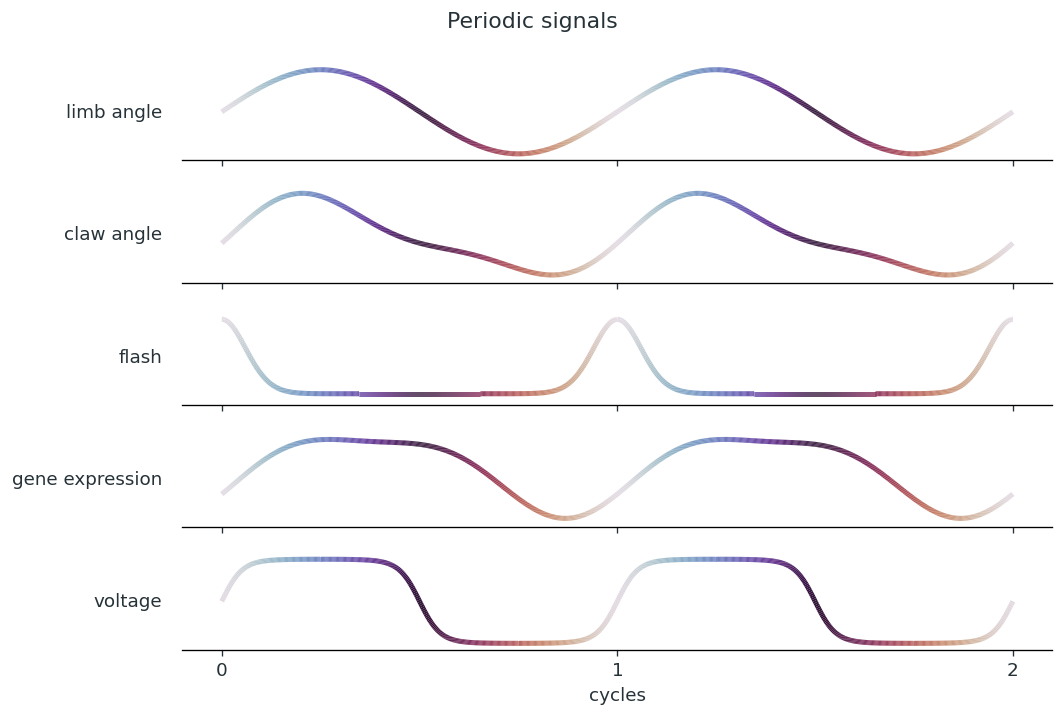

In [3]:
phase = np.linspace(0, 4 * np.pi, 900)
time = phase / (2 * np.pi)
signals = [
    ("limb angle", np.sin(phase)),
    ("claw angle", 0.72 * np.sin(phase) + 0.22 * np.sin(2 * phase - 0.5)),
    ("flash", np.exp(7 * (np.cos(phase) - 1))),
    ("gene expression", 0.65 * np.sin(phase - 0.7) + 0.18 * np.sin(2 * phase)),
    ("voltage", np.tanh(3 * np.sin(phase))),
]

fig, axes = plt.subplots(len(signals), 1, figsize=(9, 6), sharex=True)
for ax, (label, signal) in zip(axes, signals):
    colored_line(ax, time, signal, phase)
    ax.set_ylim(signal.min() - 0.15, signal.max() + 0.15)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", labelpad=12)
    ax.spines["left"].set_visible(False)

axes[-1].set(xlabel="cycles", xticks=[0, 1, 2])
fig.suptitle("Periodic signals", y=0.99)
fig.tight_layout()
plt.show()


### Periodic dynamics can be multidimensional

A trajectory is periodic if

$$
\mathbf{x}(t+T)=\mathbf{x}(t)
$$

is always true.

One cycle is a closed orbit in state space.

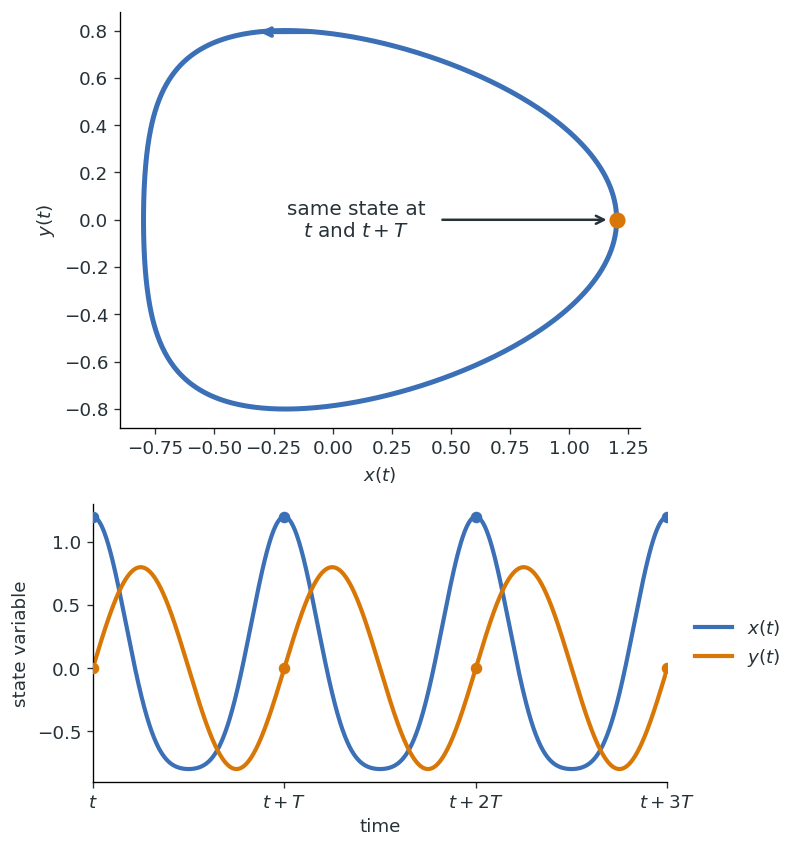

In [4]:
orbit_position = np.linspace(0, TAU, 500)
x = np.cos(orbit_position) + 0.20 * np.cos(2 * orbit_position)
y = 0.80 * np.sin(orbit_position)

trace_position = np.linspace(0, 3 * TAU, 1500)
trace_time = trace_position / TAU
x_trace = np.cos(trace_position) + 0.20 * np.cos(2 * trace_position)
y_trace = 0.80 * np.sin(trace_position)

fig, (ax_orbit, ax_time) = plt.subplots(
    2, 1, figsize=(6.8, 7.2), gridspec_kw={"height_ratios": [1.5, 1]}
)

ax_orbit.plot(x, y, color=BLUE, lw=3)
ax_orbit.scatter(x[0], y[0], s=75, color=ORANGE, zorder=3)
ax_orbit.annotate(
    "same state at\n" + r"$t$ and $t+T$",
    xy=(x[0], y[0]),
    xytext=(0.10, 0),
    ha="center", va="center", fontsize=12,
    arrowprops={
        "arrowstyle": "->", "color": INK, "lw": 1.5,
        "shrinkA": 8, "shrinkB": 6,
    },
)
ax_orbit.annotate(
    "",
    xy=(x[135], y[135]),
    xytext=(x[115], y[115]),
    arrowprops={"arrowstyle": "->", "color": BLUE, "lw": 2.5},
)
ax_orbit.set(
    xlabel=r"$x(t)$",
    ylabel=r"$y(t)$",
)
ax_orbit.set_aspect("equal", adjustable="box")

ax_time.plot(trace_time, x_trace, color=BLUE, lw=2.5, label=r"$x(t)$")
ax_time.plot(trace_time, y_trace, color=ORANGE, lw=2.5, label=r"$y(t)$")
cycle_marks = np.arange(4)
ax_time.scatter(cycle_marks, np.full(4, x[0]), color=BLUE, s=35, zorder=3)
ax_time.scatter(cycle_marks, np.full(4, y[0]), color=ORANGE, s=35, zorder=3)
ax_time.set(
    xlim=(0, 3),
    xlabel="time",
    ylabel="state variable",
    xticks=cycle_marks,
    xticklabels=[r"$t$", r"$t+T$", r"$t+2T$", r"$t+3T$"],
)
ax_time.legend(
    frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5)
)

fig.tight_layout()
plt.show()

### Phase

We will label position within the cycle by an angle:

$$
\theta\in[0,2\pi),
\qquad
\theta\equiv\theta+2\pi
$$

Along a periodic cycle, we define phase so that it advances uniformly in time:

$$
\dot\theta=\omega,
\qquad
\omega=\frac{2\pi}{T}
$$

*Next lecture we will learn how to infer $\theta(t)$ from a measured time series data...*

In [5]:
omega = 1.15
t = np.linspace(0, 2.5 * TAU / omega, 500)
theta = omega * t
phase_frames = np.linspace(0, len(t) - 1, 120, dtype=int)

fig, (ax_orbit, ax_circle, ax_time) = plt.subplots(
    1, 3, figsize=(11, 3.4),
    gridspec_kw={"width_ratios": [1, 1, 1.7]},
)

ax_orbit.plot(x, y, color=LIGHT, lw=3)
orbit_point, = ax_orbit.plot([x[0]], [y[0]], "o", color=ORANGE, ms=9, zorder=4)
ax_orbit.set(
    xlim=(x.min() - 0.12, x.max() + 0.12),
    ylim=(y.min() - 0.12, y.max() + 0.12),
    xlabel=r"$x(t)$",
    ylabel=r"$y(t)$",
)
ax_orbit.set_aspect("equal", adjustable="box")

phase_orbit = np.linspace(0, TAU, 400)
ax_circle.plot(np.cos(phase_orbit), np.sin(phase_orbit), color=LIGHT, lw=3)
phase_vector = ax_circle.quiver(
    0, 0, np.cos(theta[0]), np.sin(theta[0]),
    angles="xy", scale_units="xy", scale=1,
    width=0.025, headwidth=4.5, headlength=5.5, color=BLUE,
)
phase_circle_point, = ax_circle.plot([], [], "o", color=ORANGE, ms=8, zorder=4)
ax_circle.text(0.2, 0.15, r"$\theta$", fontsize=16)
ax_circle.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15))
ax_circle.set_aspect("equal")
ax_circle.axis("off")

ax_time.plot(t, theta, color=LIGHT, lw=3)
phase_trace, = ax_time.plot([], [], color=BLUE, lw=3)
phase_time_point, = ax_time.plot([], [], "o", color=ORANGE, ms=8, zorder=4)
for level in [TAU, 2 * TAU]:
    ax_time.axhline(level, color=LIGHT, lw=1)
ax_time.set(
    xlim=(t[0], t[-1]),
    ylim=(0, theta[-1] + 0.35),
    xlabel="time",
    ylabel=r"unwrapped phase $\theta(t)$",
    yticks=[0, TAU, 2 * TAU],
    yticklabels=["0", r"$2\pi$", r"$4\pi$"],
)

fig.tight_layout()

def update_phase_progression(frame):
    index = phase_frames[frame]
    wrapped_phase = np.mod(theta[index], TAU)
    state_x = np.cos(wrapped_phase) + 0.20 * np.cos(2 * wrapped_phase)
    state_y = 0.80 * np.sin(wrapped_phase)
    orbit_point.set_data([state_x], [state_y])
    phase_vector.set_UVC(np.cos(wrapped_phase), np.sin(wrapped_phase))
    phase_circle_point.set_data(
        [np.cos(wrapped_phase)], [np.sin(wrapped_phase)]
    )
    phase_trace.set_data(t[: index + 1], theta[: index + 1])
    phase_time_point.set_data([t[index]], [theta[index]])
    return (
        orbit_point, phase_vector, phase_circle_point,
        phase_trace, phase_time_point,
    )

phase_progression_animation = FuncAnimation(
    fig, update_phase_progression, frames=phase_frames.size,
    interval=50, blit=True, repeat=True,
)
phase_progression_video = HTML(phase_progression_animation.to_html5_video())
plt.close(fig)
phase_progression_video


### Multiple oscillators

Multiple oscillators can be coupled together so that their dynamics influence each other.

- Limbs during locomotion
- Firefly flashing
- The sun and an animals circadian rhythms

### Phase-difference coupling

For temporal synchrony, we want to consider models that couple phase oscillators together. In general, we can consider the dynamics to be governed by:

$$
\dot\theta_i
=
\omega_i
+
\frac{K}{N}\sum_{j=1}^{N}
H(\theta_j-\theta_i)
$$

The $i^{\rm th}$ oscillator advances at uniform speed $\omega_i$ but is modified in a way that tries to keep the phases of the different oscillators the same.

For now, we will consider the case where all the oscillators want to be in phase with each other...

### First-harmonic approximation

- $H$ must be periodic because the phase difference $\phi=\theta_j-\theta_i$ is an angle:
$$
H(\phi+2\pi)=H(\phi)
$$

- For symmetric reciprocal coupling, exchanging the oscillators should reverse the interaction effect:
$$
H(-\phi)=-H(\phi)
$$

A general odd periodic function is a sum of sine harmonics (Fourier series). We will keep the lowest order term:

$$
H(\phi)
=
\sum_{n=1}^{\infty} b_n\sin(n\phi)
\qquad\longrightarrow\qquad
H(\phi)\approx b_1\sin\phi
$$


### The Kuramoto model

What we've just written down is conventionally called the *Kuramoto model*:

$$
\boxed{
\dot\theta_i
=
\omega_i
+
\frac{K}{N}\sum_{j=1}^{N}
\sin(\theta_j-\theta_i)
}
$$

If $K>0$, small phase differences between oscillators tend to shrink.

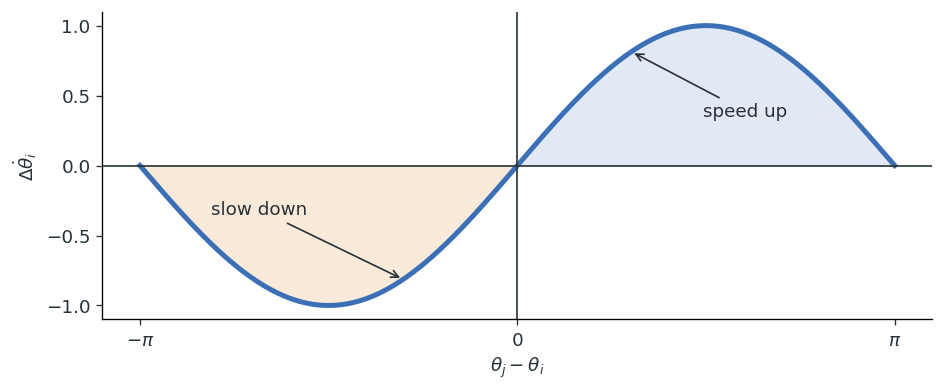

In [6]:
phi = np.linspace(-np.pi, np.pi, 600)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(phi, np.sin(phi), color=BLUE, lw=3)
ax.fill_between(
    phi, 0, np.sin(phi),
    where=(phi > 0), color=BLUE, alpha=0.15
)
ax.fill_between(
    phi, 0, np.sin(phi),
    where=(phi < 0), color=ORANGE, alpha=0.15
)
ax.axhline(0, color=INK, lw=1)
ax.axvline(0, color=INK, lw=1)
ax.annotate("speed up", (0.95, np.sin(0.95)), xytext=(1.55, 0.35),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.annotate("slow down", (-0.95, np.sin(-0.95)), xytext=(-2.55, -0.35),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.set(
    xlabel=r"$\theta_j-\theta_i$",
    ylabel=r"$\Delta \dot \theta_i$",
    xticks=[-np.pi, 0, np.pi],
    xticklabels=[r"$-\pi$", "0", r"$\pi$"]
)
fig.tight_layout()
plt.show()


## Two coupled oscillators

$$
\dot\theta_1
=
\omega_1+\frac{K}{2}\sin(\theta_2-\theta_1)
$$

$$
\dot\theta_2
=
\omega_2+\frac{K}{2}\sin(\theta_1-\theta_2)
$$

> What happens if $\theta_1 < \theta_2$?

### Mean ($\bar\theta$) and relative phase ($\phi$)

$$
\bar\theta=\frac{\theta_1+\theta_2}{2},
\qquad
\phi=\theta_2-\theta_1
$$

$$
\theta_1=\bar\theta-\frac{\phi}{2},
\qquad
\theta_2=\bar\theta+\frac{\phi}{2}
$$

Define the mean frequency ($\bar\omega$) and the detuning ($\Delta\omega$):

$$
\bar\omega=\frac{\omega_1+\omega_2}{2},
\qquad
\Delta\omega=\omega_2-\omega_1
$$

$$
\omega_1=\bar\omega-\frac{\Delta\omega}{2},
\qquad
\omega_2=\bar\omega+\frac{\Delta\omega}{2}
$$


### Mean-phase dynamics

$$
\begin{aligned}
\dot{\bar\theta}
&=\frac{\dot\theta_1+\dot\theta_2}{2}\\
&=\frac{1}{2}\left[\omega_1+\frac{K}{2}\sin(\theta_2-\theta_1)
+\omega_2+\frac{K}{2}\sin(\theta_1-\theta_2)\right]\\
&=\frac{\omega_1+\omega_2}{2}
+\frac{K}{4}\left[\sin(\theta_2-\theta_1)+\sin(\theta_1-\theta_2)\right]\\
&=\bar\omega+\frac{K}{4}\left[\sin\phi+\sin(-\phi)\right]\\
&=\bar\omega+\frac{K}{4}[\sin\phi-\sin\phi]\\
&=\bar\omega
\end{aligned}
$$

Equal-and-opposite coupling does change the mean phase dynamics!


### Relative-phase dynamics

$$
\begin{aligned}
\dot\phi
&=\dot\theta_2-\dot\theta_1\\
&=\left[\omega_2+\frac{K}{2}\sin(\theta_1-\theta_2)\right]
\quad-\left[\omega_1+\frac{K}{2}\sin(\theta_2-\theta_1)\right]\\
&=(\omega_2-\omega_1)
+\frac{K}{2}\left[\sin(\theta_1-\theta_2)-\sin(\theta_2-\theta_1)\right]\\
&=\Delta\omega+\frac{K}{2}\left[\sin(-\phi)-\sin\phi\right]\\
&=\Delta\omega+\frac{K}{2}[-\sin\phi-\sin\phi]\\
&=\boxed{\Delta\omega-K\sin\phi}
\end{aligned}
$$

> ### What does this equation tell us?
> 
> - What is $\dot\phi$?
> - When do we get *phase locking*?

### When is phase locking possible?

For attractive coupling, $K>0$, 1:1 locking means that the relative phase settles to a constant value $\phi^*$:

$$
\phi(t)=\phi^*
\quad\implies\quad
\dot\phi=0.
$$

Our relative-phase equation then requires

$$
0=\Delta\omega-K\sin\phi^*
\qquad\implies\qquad
\sin\phi^*=\frac{\Delta\omega}{K}.
$$

But a sine can take values only between $-1$ and $1$. Therefore a fixed point can exist only if

$$
-1\le\frac{\Delta\omega}{K}\le1
\qquad\implies\qquad
\boxed{|\Delta\omega|\le K}.
$$

> In the diagram below, what are the "fixed points"? Are they stable or unstable?

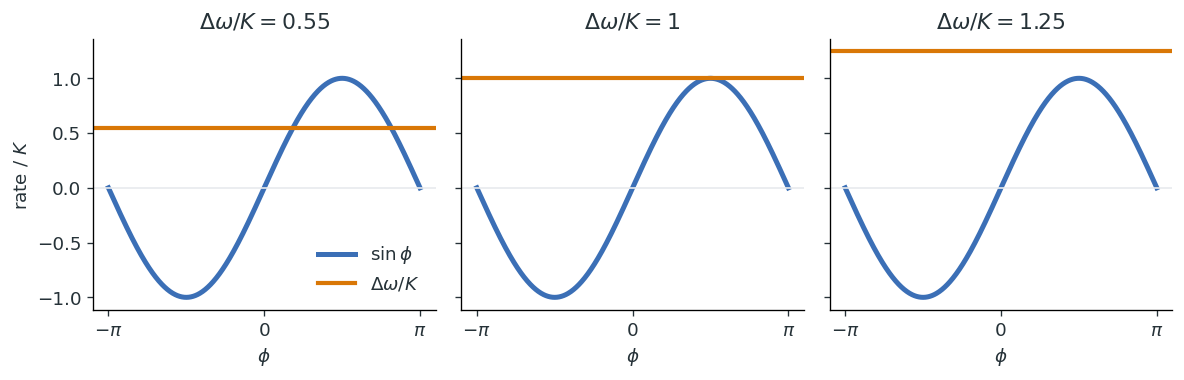

In [7]:
phi_grid = np.linspace(-np.pi, np.pi, 700)
detuning_ratios = [0.55, 1.0, 1.25]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), sharey=True)
for ax, ratio in zip(axes, detuning_ratios):
    ax.plot(phi_grid, np.sin(phi_grid), color=BLUE, lw=3, label=r"$\sin\phi$")
    ax.axhline(ratio, color=ORANGE, lw=2.5, label=r"$\Delta\omega/K$")
    ax.axhline(0, color=LIGHT, lw=1)
    ax.set(
        xlabel=r"$\phi$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        title=rf"$\Delta\omega/K={ratio:g}$",
    )
axes[0].set_ylabel("rate / $K$")
axes[0].legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()


In [8]:
from io import BytesIO

import ipywidgets as widgets
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

omega_1_slider = widgets.FloatSlider(
    value=0.8, min=0.2, max=2.0, step=0.05, description="ω₁",
    continuous_update=False, readout_format=".2f",
)
omega_2_slider = widgets.FloatSlider(
    value=1.2, min=0.2, max=2.0, step=0.05, description="ω₂",
    continuous_update=False, readout_format=".2f",
)
coupling_slider = widgets.FloatSlider(
    value=0.65, min=0.0, max=1.5, step=0.05, description="K",
    continuous_update=False, readout_format=".2f",
)

n_frames = 240
play = widgets.Play(value=0, min=0, max=n_frames - 1, interval=70)
time_slider = widgets.IntSlider(
    value=0, min=0, max=n_frames - 1, readout=False,
    layout=widgets.Layout(width="420px"),
)
widgets.jslink((play, "value"), (time_slider, "value"))
regime = widgets.HTML()
clock = widgets.HTML(layout=widgets.Layout(width="150px"))

fig = Figure(figsize=(9, 5.8), dpi=100)
render_canvas = FigureCanvasAgg(fig)
image_buffer = BytesIO()
phase_image = widgets.Image(
    format="png", layout=widgets.Layout(width="900px"),
)

grid = fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=0.28, wspace=0.12)
ax_1 = fig.add_subplot(grid[0, 0])
ax_2 = fig.add_subplot(grid[0, 1])
ax_phi = fig.add_subplot(grid[1, :])

circle = np.linspace(0, TAU, 400)
for ax, label, color in [
    (ax_1, r"$\theta_1$", BLUE),
    (ax_2, r"$\theta_2$", ORANGE),
]:
    ax.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=4)
    ax.scatter([1], [0], s=18, color=GREY, zorder=3)
    ax.text(0, -1.34, label, color=color, fontsize=15, ha="center")
    ax.set(xlim=(-1.18, 1.18), ylim=(-1.42, 1.15), aspect="equal")
    ax.axis("off")

radius_1, = ax_1.plot([], [], color=BLUE, lw=3)
dot_1, = ax_1.plot([], [], "o", color=BLUE, ms=10)
radius_2, = ax_2.plot([], [], color=ORANGE, lw=3)
dot_2, = ax_2.plot([], [], "o", color=ORANGE, ms=10)

full_phi, = ax_phi.plot([], [], color=LIGHT, lw=2)
past_phi, = ax_phi.plot([], [], color=PINK, lw=3)
now_phi, = ax_phi.plot([], [], "o", color=PINK, ms=8, zorder=4)
locked_phi = ax_phi.axhline(0, color=GREY, lw=1.5, ls="--", visible=False)
ax_phi.set(
    xlim=(0, 18), ylim=(-np.pi - 0.25, np.pi + 0.25),
    xlabel="time", ylabel=r"$\phi(t)=\theta_2-\theta_1$",
    yticks=[-np.pi, 0, np.pi], yticklabels=[r"$-\pi$", "0", r"$\pi$"],
)
ax_phi.axhline(0, color=LIGHT, lw=1, zorder=0)
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.12, top=0.98)

state = {}
theta_1_initial = 0.3
theta_2_initial = 2.0

def phase_trace_with_gaps(phi):
    trace = wrap_phase(phi).astype(float)
    trace[1:][np.abs(np.diff(trace)) > np.pi] = np.nan
    return trace

def update_frame(frame):
    index = state["frame_indices"][frame]
    theta_1 = state["theta_1"][index]
    theta_2 = state["theta_2"][index]
    x_1, y_1 = np.cos(theta_1), np.sin(theta_1)
    x_2, y_2 = np.cos(theta_2), np.sin(theta_2)
    radius_1.set_data([0, x_1], [0, y_1])
    dot_1.set_data([x_1], [y_1])
    radius_2.set_data([0, x_2], [0, y_2])
    dot_2.set_data([x_2], [y_2])
    past_phi.set_data(state["times"][:index + 1], state["phi_plot"][:index + 1])
    now_phi.set_data([state["times"][index]], [wrap_phase(state["phi"][index])])
    clock.value = (
        f"<span style='font-variant-numeric:tabular-nums'>"
        f"t = {state['times'][index]:4.1f}&nbsp;&nbsp; φ = {wrap_phase(state['phi'][index]):+4.2f}</span>"
    )
    image_buffer.seek(0)
    image_buffer.truncate()
    render_canvas.print_png(image_buffer)
    phase_image.value = image_buffer.getvalue()

def update_parameters(change=None):
    omega_1 = omega_1_slider.value
    omega_2 = omega_2_slider.value
    coupling = coupling_slider.value
    detuning = omega_2 - omega_1
    times, phi = simulate_relative_phase(
        detuning, coupling, theta_2_initial - theta_1_initial,
        t_end=18, dt=0.02,
    )
    mean_phase = 0.5 * (theta_1_initial + theta_2_initial) + 0.5 * (omega_1 + omega_2) * times
    state.update(
        times=times,
        phi=phi,
        phi_plot=phase_trace_with_gaps(phi),
        theta_1=mean_phase - 0.5 * phi,
        theta_2=mean_phase + 0.5 * phi,
        frame_indices=np.linspace(0, len(times) - 1, n_frames, dtype=int),
    )
    full_phi.set_data(times, state["phi_plot"])

    if coupling > 0 and abs(detuning) <= coupling:
        phi_star = np.arcsin(detuning / coupling)
        locked_phi.set_ydata([phi_star, phi_star])
        locked_phi.set_visible(True)
        message = "phase locking possible"
        color = OLIVE
    elif coupling == 0 and np.isclose(detuning, 0):
        locked_phi.set_visible(False)
        message = "no relative drift"
        color = OLIVE
    else:
        locked_phi.set_visible(False)
        message = "phase slips"
        color = PINK

    regime.value = (
        f"<span style='display:inline-block;padding:4px 10px;border-radius:12px;"
        f"background:{color}20;color:{color};font-weight:600'>{message}</span>"
        f"&nbsp;&nbsp; Δω = {detuning:+.2f}; &nbsp; |Δω| {'≤' if abs(detuning) <= coupling else '>'} K"
    )
    play.value = 0
    time_slider.value = 0
    update_frame(0)

for slider in (omega_1_slider, omega_2_slider, coupling_slider):
    slider.observe(update_parameters, names="value")
time_slider.observe(lambda change: update_frame(change["new"]), names="value")

update_parameters()
controls = widgets.HBox(
    [omega_1_slider, omega_2_slider, coupling_slider],
    layout=widgets.Layout(justify_content="space-between", width="900px"),
)
transport = widgets.HBox(
    [play, time_slider, clock],
    layout=widgets.Layout(align_items="center", width="900px"),
)
display(widgets.VBox([phase_image, controls, transport, regime]))


## Phase-flow diagrams

We can visualize the dynamics by plotting the *phase space* $\dot\phi$ against $\phi$. 

- Where $\dot\phi>0$, trajectories move toward increasing $\phi$
- Where $\dot\phi<0$, they move toward decreasing $\phi$.

Fixed points occur where the curve crosses $\dot\phi=0$. 

- A negative-slope crossing is stable: the flow points toward it from both sides. 
- A positive-slope crossing is unstable: the flow points away.

If the curve never crosses zero, $\phi$ drifts continuously and the oscillators undergo repeated phase slips.

In [9]:
locking_coupling = 1.0
locking_phi0 = 1.8
locking_phi0_right = 2.8
locking_detunings = [0.60, 1.20]
locking_titles = ["inside the locking range", "outside the locking range"]

locking_runs = [
    simulate_relative_phase(
        detuning, locking_coupling, locking_phi0, t_end=12, dt=0.02
    )
    for detuning in locking_detunings
]
locking_right_run = simulate_relative_phase(
    locking_detunings[0], locking_coupling, locking_phi0_right,
    t_end=12, dt=0.02
)
locking_frames = np.linspace(
    0, locking_runs[0][0].size - 1, 96, dtype=int
)
flow_phi = np.linspace(-np.pi, np.pi, 700)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
locking_points = []
locking_traces = []
locking_right_point = None
locking_right_trace = None

for column, (detuning, title, run) in enumerate(
    zip(locking_detunings, locking_titles, locking_runs)
):
    times, phases = run
    flow = detuning - locking_coupling * np.sin(flow_phi)
    axes[0, column].plot(flow_phi, flow, color=GREY, lw=3)
    axes[0, column].axhline(0, color=INK, lw=1)
    axes[0, column].set(
        xlim=(-np.pi, np.pi),
        xlabel=r"wrapped phase $\phi$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        ylabel=r"$\dot\phi$",
        title=title + rf"  ($\Delta\omega/K={detuning:g}$)",
    )
    if detuning < locking_coupling:
        stable_point = np.arcsin(detuning / locking_coupling)
        unstable_point = np.pi - stable_point
        axes[0, column].scatter(
            [stable_point], [0], color=BLUE, s=55, zorder=4, label="stable"
        )
        axes[0, column].scatter(
            [unstable_point], [0], facecolor="white", edgecolor=ORANGE,
            linewidth=2, s=55, zorder=4, label="unstable"
        )
        axes[0, column].legend(frameon=False, loc="upper right")
        axes[1, column].axhline(stable_point, color=BLUE, lw=1.5, ls="--")
        flow_intervals = [
            (-np.pi, stable_point),
            (stable_point, unstable_point),
            (unstable_point, np.pi),
        ]
        arrow_positions = [0.5 * (left + right) for left, right in flow_intervals]
    else:
        arrow_positions = [-2.2, -0.75, 0.75, 2.2]

    for arrow_phi in arrow_positions:
        direction = np.sign(
            detuning - locking_coupling * np.sin(arrow_phi)
        )
        arrow_length = 0.42
        axes[0, column].annotate(
            "",
            xy=(arrow_phi + 0.5 * direction * arrow_length, 0),
            xytext=(arrow_phi - 0.5 * direction * arrow_length, 0),
            arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.4),
            zorder=3,
        )

    point, = axes[0, column].plot([], [], "o", color="black", ms=9, zorder=5)
    trace, = axes[1, column].plot(
        [], [], color=GREY, lw=3, label=rf"$\phi_0={locking_phi0:g}$"
    )
    if column == 0:
        locking_right_point, = axes[0, column].plot(
            [], [], "o", color=ORANGE, ms=8, zorder=5
        )
        locking_right_trace, = axes[1, column].plot(
            [], [], color=ORANGE, lw=3,
            label=rf"$\phi_0={locking_phi0_right:g}$"
        )
    axes[1, column].set(
        xlim=(times[0], times[-1]),
        ylim=(min(phases.min(), locking_right_run[1].min()) - 0.35, max(phases.max(), locking_right_run[1].max()) + 0.35),
        xlabel="time",
        ylabel=r"unwrapped $\phi(t)$",
    )
    locking_points.append(point)
    locking_traces.append(trace)
    if column == 0:
        axes[1, column].legend(frameon=False, loc="lower right")

locking_time = fig.text(0.5, 0.98, "", ha="center", va="top", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))

def update_locking(frame):
    index = locking_frames[frame]
    artists = [locking_time]
    for column, (detuning, run) in enumerate(zip(locking_detunings, locking_runs)):
        times, phases = run
        wrapped_phase = wrap_phase(phases[index])
        phase_rate = detuning - locking_coupling * np.sin(wrapped_phase)
        locking_points[column].set_data([wrapped_phase], [phase_rate])
        locking_traces[column].set_data(times[: index + 1], phases[: index + 1])
        artists.extend([locking_points[column], locking_traces[column]])
        if column == 0:
            right_times, right_phases = locking_right_run
            right_wrapped_phase = wrap_phase(right_phases[index])
            right_phase_rate = detuning - locking_coupling * np.sin(right_wrapped_phase)
            locking_right_point.set_data([right_wrapped_phase], [right_phase_rate])
            locking_right_trace.set_data(
                right_times[: index + 1], right_phases[: index + 1]
            )
            artists.extend([locking_right_point, locking_right_trace])
    locking_time.set_text(rf"$t={locking_runs[0][0][index]:.1f}$")
    return artists

locking_animation = FuncAnimation(
    fig, update_locking, frames=locking_frames.size, interval=60, blit=True
)
locking_video = HTML(locking_animation.to_html5_video())
plt.close(fig)
locking_video


### We can test stability with the local slope

For the sinusoidal phase flow,

$$
\left.
\frac{d\dot\phi}{d\phi}
\right|_{\phi^*}
=
-K\cos\phi^*
$$

For attractive coupling with $|\Delta\omega|<K$, the two fixed points satisfy

$$
|\phi^*|<\frac{\pi}{2}
\Longrightarrow
\cos\phi^*>0
\Longrightarrow
\left.\frac{d\dot\phi}{d\phi}\right|_{\phi^*}<0
\Longrightarrow
\text{stable}
$$

$$
\frac{\pi}{2}<|\phi^*|\le\pi
\Longrightarrow
\cos\phi^*<0
\Longrightarrow
\left.\frac{d\dot\phi}{d\phi}\right|_{\phi^*}>0
\Longrightarrow
\text{unstable}
$$


### Linear dynamics near a fixed point

Add a small perturbation $\eta(t)$ to the fixed point:

$$
\phi(t)=\phi^*+\eta(t),
\qquad
|\eta|\ll1
$$

Because $\phi^*$ is constant, $\dot\phi=\dot\eta$. To linearize the sine term, use the angle-addition identity:

$$
\sin(\phi^*+\eta)
=\sin\phi^*\cos\eta+\cos\phi^*\sin\eta.
$$

When $|\eta|\ll1$, $\cos\eta\approx1$ and $\sin\eta\approx\eta$, so

$$
\sin(\phi^*+\eta)
\approx\sin\phi^*+\eta\cos\phi^*.
$$

Substitute this first-order approximation into the relative-phase equation:

$$
\begin{aligned}
\dot\eta
&=\Delta\omega-K\sin(\phi^*+\eta)\\
&\approx\Delta\omega-K\left(\sin\phi^*+\eta\cos\phi^*\right)\\
&=\underbrace{\Delta\omega-K\sin\phi^*}_{=0\text{ at the fixed point}}
-K\cos\phi^*\,\eta\\
&=-K\cos\phi^*\,\eta\\
&\equiv\lambda\eta
\end{aligned}
$$

$\lambda=-K\cos\phi^*$ is the local rate of growth or decay at the fixed point.

The solution to this equation is:

$$
\eta(t)=\eta_0e^{\lambda t},
$$

where $\eta_0=\eta(0)$.


In [10]:
stability_coupling = 1.0
stability_detuning = 0.60
stable_point = np.arcsin(stability_detuning / stability_coupling)
unstable_point = np.pi - stable_point
fixed_points = [stable_point, unstable_point]
initial_perturbations = [0.10, -0.10]
stability_titles = ["perturb the stable state", "perturb the unstable state"]
stability_colors = [BLUE, ORANGE]
stability_lambdas = [
    -stability_coupling * np.cos(point) for point in fixed_points
]
stability_runs = [
    simulate_relative_phase(
        stability_detuning, stability_coupling, point + perturbation,
        t_end=9, dt=0.02
    )
    for point, perturbation in zip(fixed_points, initial_perturbations)
]
stability_frames = np.linspace(
    0, stability_runs[0][0].size - 1, 96, dtype=int
)
stability_phi = np.linspace(-np.pi, np.pi, 700)
stability_flow = stability_detuning - stability_coupling * np.sin(stability_phi)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
stability_points_artist = []
stability_full_traces = []
stability_linear_traces = []
stability_full_errors = []
stability_linear_errors = []

for column, (point, perturbation, rate, title, color, run) in enumerate(
    zip(
        fixed_points, initial_perturbations, stability_lambdas,
        stability_titles, stability_colors, stability_runs
    )
):
    times, phases = run
    full_error = np.abs(wrap_phase(phases - point))
    linear_error = np.abs(perturbation * np.exp(rate * times))
    if rate > 0:
        linear_error = np.where(linear_error <= 0.60, linear_error, np.nan)
    stability_full_errors.append(full_error)
    stability_linear_errors.append(linear_error)

    axes[0, column].plot(stability_phi, stability_flow, color=GREY, lw=2.5)
    axes[0, column].axhline(0, color=INK, lw=1)
    axes[0, column].scatter(
        [stable_point], [0], color=BLUE, s=55, zorder=4, label="stable"
    )
    axes[0, column].scatter(
        [unstable_point], [0], facecolor="white", edgecolor=ORANGE,
        linewidth=2, s=55, zorder=4, label="unstable"
    )
    moving_point, = axes[0, column].plot([], [], "o", color=INK, ms=9, zorder=5)
    axes[0, column].set(
        xlim=(-np.pi, np.pi),
        xlabel=r"$\phi$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        ylabel=r"$\dot\phi$",
        title=title + rf"  ($\lambda={rate:+.2f}$)",
    )
    axes[0, column].legend(frameon=False, loc="lower left")

    full_trace, = axes[1, column].semilogy(
        [], [], color=color, lw=3, label="full dynamics"
    )
    linear_trace, = axes[1, column].semilogy(
        [], [], color=INK, lw=2, ls="--", label=r"$|\eta_0|e^{\lambda t}$"
    )
    axes[1, column].set(
        xlim=(times[0], times[-1]),
        ylim=(1e-4, 2.5),
        xlabel="time",
        ylabel=r"distance from fixed point $|\eta|$",
    )
    axes[1, column].legend(frameon=False, loc="best")
    stability_points_artist.append(moving_point)
    stability_full_traces.append(full_trace)
    stability_linear_traces.append(linear_trace)

stability_time = fig.text(0.5, 0.98, "", ha="center", va="top", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))

def update_stability(frame):
    index = stability_frames[frame]
    artists = [stability_time]
    for column, (point, run) in enumerate(zip(fixed_points, stability_runs)):
        times, phases = run
        wrapped_phase = wrap_phase(phases[index])
        phase_rate = stability_detuning - stability_coupling * np.sin(wrapped_phase)
        stability_points_artist[column].set_data([wrapped_phase], [phase_rate])
        stability_full_traces[column].set_data(
            times[: index + 1], stability_full_errors[column][: index + 1]
        )
        stability_linear_traces[column].set_data(
            times[: index + 1], stability_linear_errors[column][: index + 1]
        )
        artists.extend([
            stability_points_artist[column], stability_full_traces[column],
            stability_linear_traces[column]
        ])
    stability_time.set_text(rf"$t={stability_runs[0][0][index]:.1f}$")
    return artists

stability_animation = FuncAnimation(
    fig, update_stability, frames=stability_frames.size, interval=60, blit=True
)
stability_video = HTML(stability_animation.to_html5_video())
plt.close(fig)
stability_video


In [ ]:
#

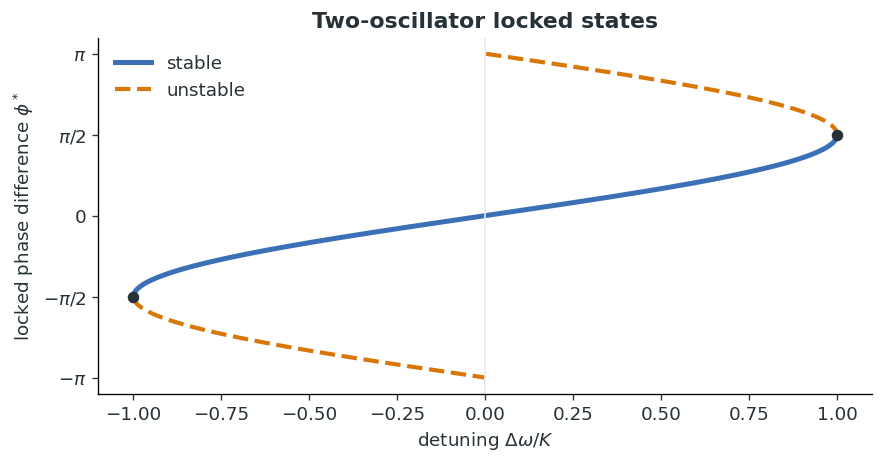

In [11]:
detuning_ratio = np.linspace(-1, 1, 500)
stable_phi = np.arcsin(detuning_ratio)
unstable_phi = wrap_phase(np.pi - stable_phi)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(detuning_ratio, stable_phi, color=BLUE, lw=3, label="stable")
negative = detuning_ratio < 0
positive = ~negative
ax.plot(
    detuning_ratio[negative],
    unstable_phi[negative],
    color=ORANGE,
    lw=2.5,
    ls="--",
    label="unstable",
)
ax.plot(
    detuning_ratio[positive],
    unstable_phi[positive],
    color=ORANGE,
    lw=2.5,
    ls="--",
)
ax.scatter([-1, 1], [-np.pi / 2, np.pi / 2], color=INK, s=35, zorder=4)
ax.axvline(0, color=LIGHT, lw=1)
ax.set(
    xlabel=r"detuning $\Delta\omega/K$",
    ylabel=r"locked phase difference $\phi^*$",
    yticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    yticklabels=[r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"],
    title="Two-oscillator locked states",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### Repulsive coupling, $K<0$

For $K<0$, small phase differences are driven *away* from zero.

Set $\Delta\omega=0$ to isolate the effect of the sign of $K$:

$$
\dot\phi=-K\sin\phi
$$

$$
\dot\phi(t)=0
\quad\Longrightarrow\quad
\sin\phi^*=0
\quad\Longrightarrow\quad
\phi^*=0,\ \pi
\pmod{2\pi}
$$

BUT:

$$
\left.\frac{d\dot\phi}{d\phi}\right|_{\phi^*=0}=-K,
\qquad
\left.\frac{d\dot\phi}{d\phi}\right|_{\phi^*=\pi}=K
$$

$$
K>0:\quad \phi^*=0\ \text{stable},\quad \phi^*=\pi\ \text{unstable}
$$

$$
K<0:\quad \phi^*=0\ \text{unstable},\quad \phi^*=\pi\ \text{stable}
$$

With repulsive coupling, a small phase difference grows until the oscillators lock in *anti-phase*: their phases remain separated by $\pi$, or half a cycle.


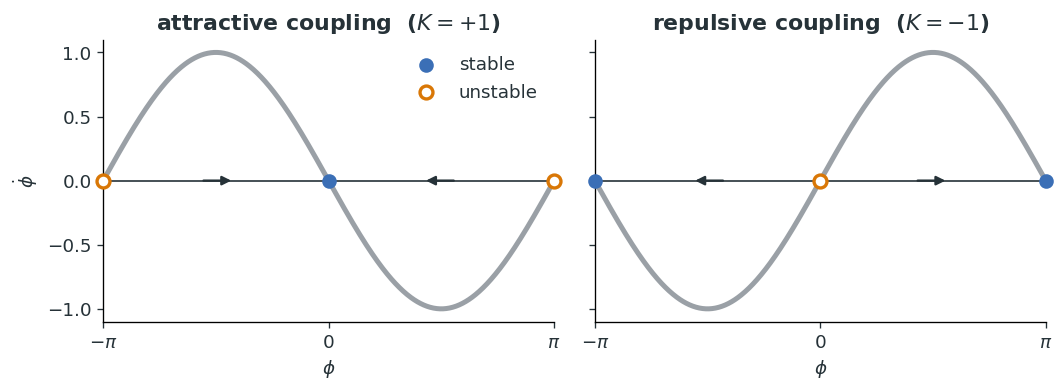

In [12]:
phi_grid = np.linspace(-np.pi, np.pi, 700)
couplings = [1, -1]
coupling_titles = ["attractive coupling", "repulsive coupling"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for column, (ax, coupling, title) in enumerate(
    zip(axes, couplings, coupling_titles)
):
    flow = -coupling * np.sin(phi_grid)
    ax.plot(phi_grid, flow, color=GREY, lw=3)
    ax.axhline(0, color=INK, lw=1)
    ax.set(
        xlim=(-np.pi, np.pi),
        xlabel=r"$\phi$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        title=title + rf"  ($K={coupling:+d}$)",
    )

    for arrow_phi in [-1.55, 1.55]:
        direction = np.sign(-coupling * np.sin(arrow_phi))
        ax.annotate(
            "",
            xy=(arrow_phi + 0.24 * direction, 0),
            xytext=(arrow_phi - 0.24 * direction, 0),
            arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.4),
            zorder=3,
        )

    if coupling > 0:
        stable_points = [0]
        unstable_points = [-np.pi, np.pi]
    else:
        stable_points = [-np.pi, np.pi]
        unstable_points = [0]

    ax.scatter(
        stable_points, np.zeros(len(stable_points)), color=BLUE, s=60,
        zorder=4, clip_on=False, label="stable" if column == 0 else None,
    )
    ax.scatter(
        unstable_points, np.zeros(len(unstable_points)),
        facecolor="white", edgecolor=ORANGE, linewidth=2, s=60,
        zorder=4, clip_on=False, label="unstable" if column == 0 else None,
    )

axes[0].set_ylabel(r"$\dot\phi$")
axes[0].legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


In [19]:
from io import BytesIO

import ipywidgets as widgets
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

repulsive_omega_1_slider = widgets.FloatSlider(
    value=0.8, min=0.2, max=2.0, step=0.05, description="ω₁",
    continuous_update=False, readout_format=".2f",
)
repulsive_omega_2_slider = widgets.FloatSlider(
    value=1.2, min=0.2, max=2.0, step=0.05, description="ω₂",
    continuous_update=False, readout_format=".2f",
)
repulsive_coupling_slider = widgets.FloatSlider(
    value=-0.65, min=-1.5, max=0.0, step=0.05, description="K<0",
    continuous_update=False, readout_format=".2f",
)

repulsive_n_frames = 240
repulsive_play = widgets.Play(value=0, min=0, max=repulsive_n_frames - 1, interval=70)
repulsive_time_slider = widgets.IntSlider(
    value=0, min=0, max=repulsive_n_frames - 1, readout=False,
    layout=widgets.Layout(width="420px"),
)
widgets.jslink((repulsive_play, "value"), (repulsive_time_slider, "value"))
repulsive_regime = widgets.HTML()
repulsive_clock = widgets.HTML(layout=widgets.Layout(width="150px"))

repulsive_fig = Figure(figsize=(9, 5.8), dpi=100)
repulsive_render_canvas = FigureCanvasAgg(repulsive_fig)
repulsive_image_buffer = BytesIO()
repulsive_phase_image = widgets.Image(
    format="png", layout=widgets.Layout(width="900px"),
)

repulsive_grid = repulsive_fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=0.28, wspace=0.12)
repulsive_ax_1 = repulsive_fig.add_subplot(repulsive_grid[0, 0])
repulsive_ax_2 = repulsive_fig.add_subplot(repulsive_grid[0, 1])
repulsive_ax_phi = repulsive_fig.add_subplot(repulsive_grid[1, :])

repulsive_circle = np.linspace(0, TAU, 400)
for ax, label, color in [
    (repulsive_ax_1, r"$\theta_1$", BLUE),
    (repulsive_ax_2, r"$\theta_2$", ORANGE),
]:
    ax.plot(np.cos(repulsive_circle), np.sin(repulsive_circle), color=LIGHT, lw=4)
    ax.scatter([1], [0], s=18, color=GREY, zorder=3)
    ax.text(0, -1.34, label, color=color, fontsize=15, ha="center")
    ax.set(xlim=(-1.18, 1.18), ylim=(-1.42, 1.15), aspect="equal")
    ax.axis("off")

repulsive_radius_1, = repulsive_ax_1.plot([], [], color=BLUE, lw=3)
repulsive_dot_1, = repulsive_ax_1.plot([], [], "o", color=BLUE, ms=10)
repulsive_radius_2, = repulsive_ax_2.plot([], [], color=ORANGE, lw=3)
repulsive_dot_2, = repulsive_ax_2.plot([], [], "o", color=ORANGE, ms=10)

repulsive_full_phi, = repulsive_ax_phi.plot([], [], color=LIGHT, lw=2)
repulsive_past_phi, = repulsive_ax_phi.plot([], [], color=PINK, lw=3)
repulsive_now_phi, = repulsive_ax_phi.plot([], [], "o", color=PINK, ms=8, zorder=4)
repulsive_locked_phi = repulsive_ax_phi.axhline(0, color=GREY, lw=1.5, ls="--", visible=False)
repulsive_ax_phi.set(
    xlim=(0, 18), ylim=(-np.pi - 0.25, np.pi + 0.25),
    xlabel="time", ylabel=r"$\phi(t)=\theta_2-\theta_1$",
    yticks=[-np.pi, 0, np.pi], yticklabels=[r"$-\pi$", "0", r"$\pi$"],
)
repulsive_ax_phi.axhline(0, color=LIGHT, lw=1, zorder=0)
repulsive_fig.subplots_adjust(left=0.11, right=0.98, bottom=0.12, top=0.98)

repulsive_state = {}
repulsive_theta_1_initial = 0.3
repulsive_theta_2_initial = 2.0

def repulsive_phase_trace_with_gaps(phi):
    trace = wrap_phase(phi).astype(float)
    trace[1:][np.abs(np.diff(trace)) > np.pi] = np.nan
    return trace

def repulsive_update_frame(frame):
    index = repulsive_state["frame_indices"][frame]
    theta_1 = repulsive_state["theta_1"][index]
    theta_2 = repulsive_state["theta_2"][index]
    x_1, y_1 = np.cos(theta_1), np.sin(theta_1)
    x_2, y_2 = np.cos(theta_2), np.sin(theta_2)
    repulsive_radius_1.set_data([0, x_1], [0, y_1])
    repulsive_dot_1.set_data([x_1], [y_1])
    repulsive_radius_2.set_data([0, x_2], [0, y_2])
    repulsive_dot_2.set_data([x_2], [y_2])
    repulsive_past_phi.set_data(repulsive_state["times"][:index + 1], repulsive_state["phi_plot"][:index + 1])
    repulsive_now_phi.set_data([repulsive_state["times"][index]], [wrap_phase(repulsive_state["phi"][index])])
    repulsive_clock.value = (
        f"<span style='font-variant-numeric:tabular-nums'>"
        f"t = {repulsive_state['times'][index]:4.1f}&nbsp;&nbsp; φ = {wrap_phase(repulsive_state['phi'][index]):+4.2f}</span>"
    )
    repulsive_image_buffer.seek(0)
    repulsive_image_buffer.truncate()
    repulsive_render_canvas.print_png(repulsive_image_buffer)
    repulsive_phase_image.value = repulsive_image_buffer.getvalue()

def repulsive_update_parameters(change=None):
    omega_1 = repulsive_omega_1_slider.value
    omega_2 = repulsive_omega_2_slider.value
    coupling = repulsive_coupling_slider.value
    detuning = omega_2 - omega_1
    times, phi = simulate_relative_phase(
        detuning, coupling, repulsive_theta_2_initial - repulsive_theta_1_initial,
        t_end=18, dt=0.02,
    )
    mean_phase = 0.5 * (repulsive_theta_1_initial + repulsive_theta_2_initial) + 0.5 * (omega_1 + omega_2) * times
    repulsive_state.update(
        times=times,
        phi=phi,
        phi_plot=repulsive_phase_trace_with_gaps(phi),
        theta_1=mean_phase - 0.5 * phi,
        theta_2=mean_phase + 0.5 * phi,
        frame_indices=np.linspace(0, len(times) - 1, repulsive_n_frames, dtype=int),
    )
    repulsive_full_phi.set_data(times, repulsive_state["phi_plot"])

    if coupling < 0 and abs(detuning) <= -coupling:
        phi_star = wrap_phase(np.pi - np.arcsin(detuning / coupling))
        repulsive_locked_phi.set_ydata([phi_star, phi_star])
        repulsive_locked_phi.set_visible(True)
        message = "repulsive phase locking possible"
        color = OLIVE
    elif coupling == 0 and np.isclose(detuning, 0):
        repulsive_locked_phi.set_visible(False)
        message = "no relative drift"
        color = OLIVE
    else:
        repulsive_locked_phi.set_visible(False)
        message = "phase slips"
        color = PINK

    repulsive_regime.value = (
        f"<span style='display:inline-block;padding:4px 10px;border-radius:12px;"
        f"background:{color}20;color:{color};font-weight:600'>{message}</span>"
        f"&nbsp;&nbsp; Δω = {detuning:+.2f}; &nbsp; |Δω| {'≤' if abs(detuning) <= abs(coupling) else '>'} |K|"
    )
    repulsive_play.value = 0
    repulsive_time_slider.value = 0
    repulsive_update_frame(0)

for repulsive_slider in (repulsive_omega_1_slider, repulsive_omega_2_slider, repulsive_coupling_slider):
    repulsive_slider.observe(repulsive_update_parameters, names="value")
repulsive_time_slider.observe(lambda change: repulsive_update_frame(change["new"]), names="value")

repulsive_update_parameters()
repulsive_controls = widgets.HBox(
    [repulsive_omega_1_slider, repulsive_omega_2_slider, repulsive_coupling_slider],
    layout=widgets.Layout(justify_content="space-between", width="900px"),
)
repulsive_transport = widgets.HBox(
    [repulsive_play, repulsive_time_slider, repulsive_clock],
    layout=widgets.Layout(align_items="center", width="900px"),
)
display(widgets.VBox([repulsive_phase_image, repulsive_controls, repulsive_transport, repulsive_regime]))


### Tilted-washboard potential

The one-dimensional dynamics for *attractive* coupling ($K>0$) can be represented as overdamped (no inertia) motion down an effective potential $V(\phi)$:

$$
\dot\phi=-\frac{dV}{d\phi}
$$

$$
\dot\phi=\Delta\omega-K\sin\phi
\quad\Longrightarrow\quad
\frac{dV}{d\phi}
=-\Delta\omega+K\sin\phi
\quad\Longrightarrow\quad
\boxed{V(\phi)=-\Delta\omega\,\phi-K\cos\phi}
$$

- $-\Delta\omega\,\phi$ tilts the entire landscape
- $-K\cos\phi$ creates periodic wells and barriers

Minima of $V$ are stable fixed points; maxima are unstable fixed points.

Number of fixed points depends on $K$:

- $|\Delta\omega|<K$: wells remain, so $\phi$ can become trapped — phase locking
- $|\Delta\omega|=K$: a minimum and maximum merge; the barrier vanishes
- $|\Delta\omega|>K$: $V$ is monotonic, so $\phi$ runs downhill through repeated phase slips


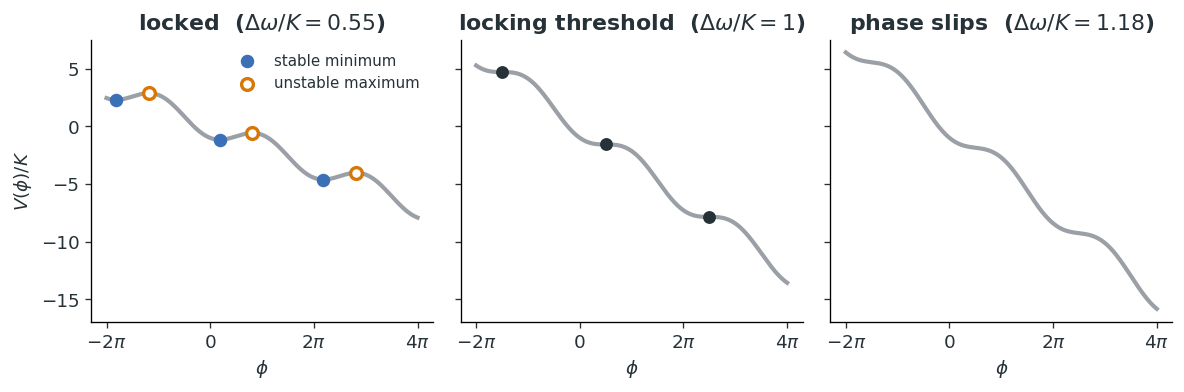

In [13]:
phi_grid = np.linspace(-2 * np.pi, 4 * np.pi, 1000)
ratios = [0.55, 1.0, 1.18]
potential_titles = ["locked", "locking threshold", "phase slips"]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
for column, (ax, ratio, title) in enumerate(
    zip(axes, ratios, potential_titles)
):
    potential = -ratio * phi_grid - np.cos(phi_grid)
    ax.plot(phi_grid, potential, color=GREY, lw=2.5)
    ax.set(
        xlabel=r"$\phi$",
        xticks=[-2 * np.pi, 0, 2 * np.pi, 4 * np.pi],
        xticklabels=[r"$-2\pi$", "0", r"$2\pi$", r"$4\pi$"],
        title=title + rf"  ($\Delta\omega/K={ratio:g}$)",
    )

    periods = np.array([-1, 0, 1])
    if ratio < 1:
        stable_points = np.arcsin(ratio) + TAU * periods
        unstable_points = np.pi - np.arcsin(ratio) + TAU * periods
        stable_values = -ratio * stable_points - np.cos(stable_points)
        unstable_values = -ratio * unstable_points - np.cos(unstable_points)
        ax.scatter(
            stable_points, stable_values, color=BLUE, s=50, zorder=4,
            label="stable minimum",
        )
        ax.scatter(
            unstable_points, unstable_values, facecolor="white",
            edgecolor=ORANGE, linewidth=2, s=50, zorder=4,
            label="unstable maximum",
        )
        ax.legend(frameon=False, loc="upper right", fontsize=9)
    elif np.isclose(ratio, 1):
        merged_points = np.pi / 2 + TAU * periods
        merged_values = -ratio * merged_points - np.cos(merged_points)
        ax.scatter(
            merged_points, merged_values, color=INK, s=45, zorder=4,
        )

axes[0].set_ylabel(r"$V(\phi)/K$")
fig.tight_layout()
plt.show()


## $N$ coupled oscillators

For $N$ oscillators, 

$$
\dot\theta_i
=
\omega_i
+
\frac{K}{N}\sum_{j=1}^{N}
\sin(\theta_j-\theta_i)
$$


### Complex order parameter

How do you average phase variables, which live on a circle?

Map each phase to the unit circle in the complex plane:

$$
e^{i\theta_j}
=
\cos\theta_j+i\sin\theta_j
$$

Define the complex average:

$$
Z
=
\frac{1}{N}\sum_{j=1}^{N}e^{i\theta_j}
$$

Write $Z$ in polar form:

$$
Z
=
Re^{i\Psi}, \quad 
R=|Z|,
\qquad
\Psi=\arg Z
$$

- $R\in[0,1]$, the *order parameter*, measures phase alignment: 
    - $R=1$ when all phases are equal = *synchrony*
    - $R=0$ when the complex numbers cancel = *incoherent*
- $\Psi$ is the angle of the complex average—the collective phase (defined when $R\neq0$).


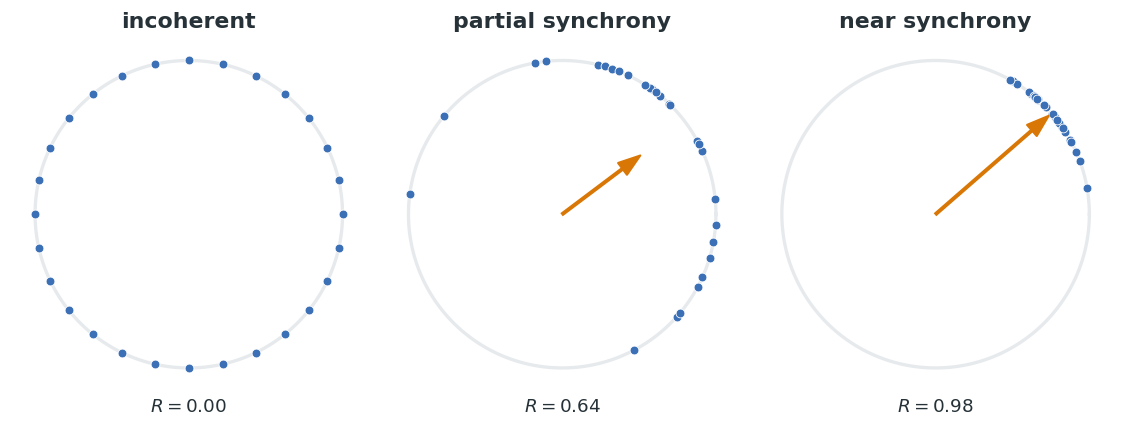

In [15]:
incoherent = np.linspace(0, TAU, 28, endpoint=False)
partial = rng.vonmises(mu=0.65, kappa=1.6, size=28)
synchronized = rng.vonmises(mu=0.65, kappa=18, size=28)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
for ax, phases, title in zip(
    axes,
    [incoherent, partial, synchronized],
    ["incoherent", "partial synchrony", "near synchrony"],
):
    draw_phase_cloud(ax, phases, title=title)
fig.tight_layout()
plt.show()


### Note: $R$ DOES NOT specify the phase distribution

Example: Compare these two phase distributions. Both have the same $R=0$.


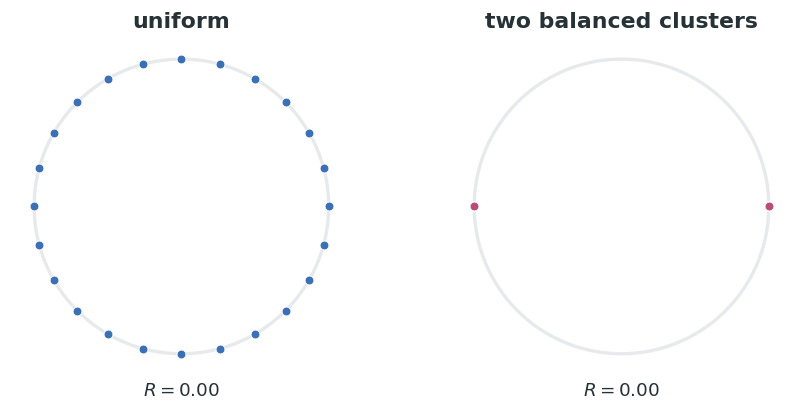

In [16]:
uniform_phases = np.linspace(0, TAU, 24, endpoint=False)
two_clusters = np.r_[np.zeros(12), np.full(12, np.pi)]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))
draw_phase_cloud(axes[0], uniform_phases, title="uniform")
draw_phase_cloud(axes[1], two_clusters, color=PINK, title="two balanced clusters")
fig.tight_layout()
plt.show()


### Mean-field reduction

The coupling term for oscillator $i$ contains $\frac{1}{N}\sum_j\sin(\theta_j-\theta_i)$. We can rewrite the order parameter to eliminate the sum, using $R$ and $\Psi$.

Multiply $Z$ by $e^{-i\theta_i}$. This rotates every phase into the reference frame of oscillator $i$:

$$
Ze^{-i\theta_i}
=
\left(\frac{1}{N}\sum_{j=1}^{N}e^{i\theta_j}\right)e^{-i\theta_i}
=
\frac{1}{N}\sum_{j=1}^{N} e^{i(\theta_j-\theta_i)}
$$

Using $Z=Re^{i\Psi}$, the same quantity is

$$
Ze^{-i\theta_i}
=
Re^{i(\Psi-\theta_i)}.
$$

Take the imaginary parts of these two expressions:

$$
\frac{1}{N}\sum_{j=1}^{N}\sin(\theta_j-\theta_i)
=
R\sin(\Psi-\theta_i)
$$


### Self-generated mean field

Substitute the mean-field reduction into each oscillator equation. The population sets $R$ and $\Psi$, and this *mean field* acts on every oscillator.

$$
\boxed{
\dot\theta_i
=
\omega_i+KR\sin(\Psi-\theta_i)
}
$$

As $K$ increases, the coherence $R$ of the population increases.



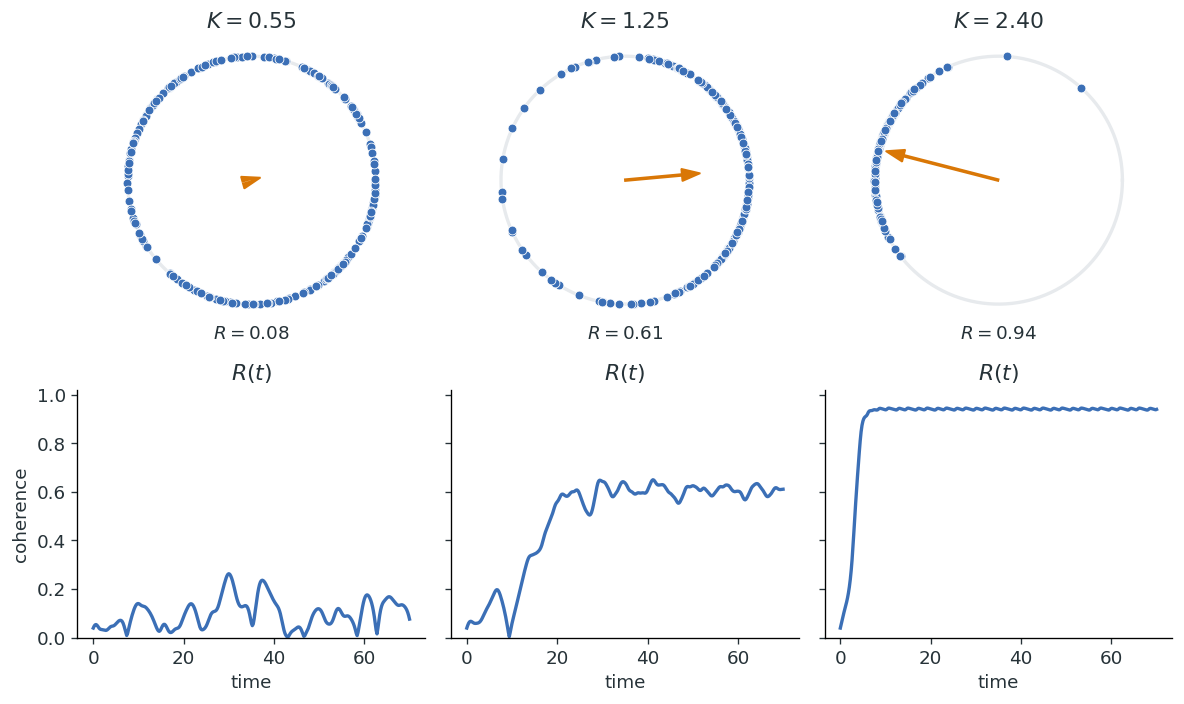

In [17]:
population_size = 240
positive_frequencies = np.abs(
    rng.normal(0, 0.70, population_size // 2)
)
natural_frequencies = np.r_[
    -positive_frequencies,
    positive_frequencies,
]
initial_phases = rng.uniform(-np.pi, np.pi, population_size)
coupling_values = [0.55, 1.25, 2.40]

fig, axes = plt.subplots(
    2, 3, figsize=(10, 6),
    gridspec_kw={"height_ratios": [1.15, 1]},
)

for column, coupling in enumerate(coupling_values):
    times, phases = simulate_kuramoto(
        natural_frequencies,
        coupling,
        initial_phases,
        t_end=70,
        dt=0.02,
        save_every=10,
    )
    coherence = np.abs(order_parameter(phases, axis=1))
    draw_phase_cloud(
        axes[0, column],
        wrap_phase(phases[-1]),
        title=rf"$K={coupling:.2f}$",
    )
    axes[1, column].plot(times, coherence, color=BLUE, lw=2)
    axes[1, column].set(
        xlabel="time",
        ylim=(0, 1.02),
        title=r"$R(t)$",
    )
    if column == 0:
        axes[1, column].set_ylabel("coherence")
    else:
        axes[1, column].set_yticklabels([])

fig.tight_layout()
plt.show()


In [ ]:
population_animation_frequencies = 1.0 + rng.normal(
    0.0, 0.12, population_size
)
population_animation_coupling_values = [0.05, 0.65, 2.40]
population_animation_runs = [
    simulate_kuramoto(
        population_animation_frequencies,
        coupling,
        initial_phases,
        t_end=70,
        dt=0.02,
        save_every=10,
    )
    for coupling in population_animation_coupling_values
]
population_animation_frames = np.linspace(
    0, population_animation_runs[0][0].size - 1, 140, dtype=int
)

fig, axes = plt.subplots(
    2, 3, figsize=(10, 6),
    gridspec_kw={"height_ratios": [1.15, 1]},
)
population_phase_points = []
population_phase_vectors = []
population_coherence_traces = []
population_coherence_now = []

circle = np.linspace(0, TAU, 400)
for column, (coupling, run) in enumerate(
    zip(population_animation_coupling_values, population_animation_runs)
):
    times, phases = run
    ax_phase = axes[0, column]
    ax_phase.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=2)
    phase_point = ax_phase.scatter(
        np.cos(phases[0]), np.sin(phases[0]),
        s=24, color=BLUE, edgecolor="white", linewidth=0.3, zorder=3,
    )
    z = order_parameter(phases[0])
    phase_vector = ax_phase.quiver(
        0, 0, z.real, z.imag,
        angles="xy", scale_units="xy", scale=1,
        width=0.018, headwidth=4, headlength=5, color=ORANGE, zorder=4,
    )
    ax_phase.set(
        xlim=(-1.15, 1.15), ylim=(-1.15, 1.15),
        title=rf"$K={coupling:.2f}$",
    )
    ax_phase.set_aspect("equal")
    ax_phase.axis("off")
    population_phase_points.append(phase_point)
    population_phase_vectors.append(phase_vector)

    coherence = np.abs(order_parameter(phases, axis=1))
    axes[1, column].plot(times, coherence, color=LIGHT, lw=2)
    coherence_trace, = axes[1, column].plot([], [], color=BLUE, lw=2.5)
    coherence_point, = axes[1, column].plot([], [], "o", color=ORANGE, ms=7, zorder=4)
    axes[1, column].set(
        xlim=(times[0], times[-1]), ylim=(0, 1.02),
        xlabel="time", title=r"$R(t)$",
    )
    if column == 0:
        axes[1, column].set_ylabel("coherence")
    else:
        axes[1, column].set_yticklabels([])
    population_coherence_traces.append(coherence_trace)
    population_coherence_now.append(coherence_point)

fig.tight_layout(rect=(0, 0, 1, 0.96))
population_animation_time = fig.text(
    0.5, 0.98, "", ha="center", va="top", weight="bold"
)

def update_population_animation(frame):
    index = population_animation_frames[frame]
    artists = [population_animation_time]
    for column, run in enumerate(population_animation_runs):
        times, phases = run
        current_phases = phases[index]
        wrapped_phases = wrap_phase(current_phases)
        population_phase_points[column].set_offsets(
            np.column_stack([np.cos(wrapped_phases), np.sin(wrapped_phases)])
        )
        z = order_parameter(current_phases)
        population_phase_vectors[column].set_UVC(z.real, z.imag)
        coherence = np.abs(order_parameter(phases, axis=1))
        population_coherence_traces[column].set_data(
            times[:index + 1], coherence[:index + 1]
        )
        population_coherence_now[column].set_data(
            [times[index]], [coherence[index]]
        )
        artists.extend([
            population_phase_points[column],
            population_phase_vectors[column],
            population_coherence_traces[column],
            population_coherence_now[column],
        ])
    population_animation_time.set_text(
        rf"$t={population_animation_runs[0][0][index]:.1f}$"
    )
    return artists

population_animation = FuncAnimation(
    fig, update_population_animation,
    frames=population_animation_frames.size,
    interval=60, blit=True, repeat=True,
)
population_animation_video = HTML(population_animation.to_html5_video())
plt.close(fig)
population_animation_video


## Sources

- Yoshiki Kuramoto, [“Self-entrainment of a population of coupled non-linear oscillators”](https://doi.org/10.1007/BFb0013365) (1975).
- Steven H. Strogatz, [“From Kuramoto to Crawford”](https://doi.org/10.1016/S0167-2789(00)00094-4) (2000).
- Juan A. Acebrón *et al.*, [“The Kuramoto model: A simple paradigm for synchronization phenomena”](https://doi.org/10.1103/RevModPhys.77.137) (2005).
- Robert Adler, [“A study of locking phenomena in oscillators”](https://doi.org/10.1109/JRPROC.1946.229930) (1946).
